# Validation on UNIFORM case

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from pathlib import Path
from wrf_io import postproc
from MITRotor import IEA10MW

In [4]:
save_path = '/scratch/09909/smata/induction_modeling/les_bem_validation/uniform/'

In [5]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [6]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/*/input_sounding")

data = extract_columns(file_list)

In [85]:
fontsize = 20
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 
plt.rcParams['figure.dpi']      = 300

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [8]:
casenames = [
r's000000_v000000',
]

In [9]:
wrfles_bem = []
for count, name in enumerate(casenames):
    wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/'+casenames[count]+'_lite.npz')))

In [10]:
def rotor_average(f, r, theta):
    dr = np.gradient(r)
    dtheta = np.gradient(theta)

    area_elements = np.outer(dr * r, dtheta)
    integrand = f * area_elements

    A = np.pi * (1 - r[0]**2)

    area_avg = np.sum(integrand) / A

    return area_avg

In [11]:
def annulus_average(f, theta):

    dtheta = np.gradient(theta)
    weights = dtheta / np.sum(dtheta)
    X_azim = np.sum(f * weights, axis=1)

    return X_azim

In [12]:
def annulus_to_rotor_average(f, r):

    dr = np.gradient(r)
    area_elements = 2 * np.pi * r * dr  # differential area for annular rings
    integrand = f * area_elements

    A = np.pi * (1 - r[0]**2)  # total area of annulus from R1 to R2

    X_rotor =  np.sum(integrand) / A

    return X_rotor

In [13]:
t = np.linspace(0,2*np.pi,wrfles_bem[0]['Nsct'])
r = np.linspace(0,1,wrfles_bem[0]['Nelm'])

rho = 1.225

hh = wrfles_bem[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles_bem[0]['radius'] + hh

wrf_ind      = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))
wrf_cot      = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_tsr      = np.zeros(len(casenames), dtype=float)
wrf_omg      = np.zeros(len(casenames), dtype=float)

wrf_cax      = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_vax_real = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))
wrf_vtn_real = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_vax      = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))
wrf_vtn      = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_CL       = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))
wrf_CD       = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_CL_real  = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))
wrf_CD_real  = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_L_real   = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))
wrf_D_real   = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_FN_real  = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))
wrf_FT_real  = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_phi      = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_phi_real = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_aoa      = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_aoa_real = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_pow_real = np.zeros(len(casenames), dtype=float)
wrf_thr_real = np.zeros(len(casenames), dtype=float)

U_loc        = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))
dir_loc      = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

u            = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))
v            = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))
wrf_W        = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

wrf_W_real   = np.zeros((wrfles_bem[0]['Nelm'], wrfles_bem[0]['Nsct'], len(casenames)))

shapiro      = np.zeros(len(casenames), dtype=float)

Uhub         = np.zeros(len(casenames), dtype=float)

rotor = IEA10MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles_bem[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract u and v velocity components at the rotor disk
    u_rotor = np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0)
    v_rotor = np.mean(wrfles_bem[count]['v'],axis=0)

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles_bem[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles_bem[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(hh)**2 + v_func(hh)**2)

    # Induction
    a_bar = 0

    # Radial chord lengths
    chord = [4.6676990,4.9464440,5.2251880,5.5039330,5.7826780,5.9548990,5.9173600,5.6191650,5.3209710,5.0227760,4.7245810,4.4263860,4.1281910,3.8143440,3.4913100,3.1830230,2.9108200,2.6386170,2.3471500,2.0470230,1.7468950,1.4467680,1.1466410,0.8465134,0.5463862,0.2462587]
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = [11.83793000,11.16304000,10.48815000,9.81326400,9.13837600,7.98429600,6.42827500,5.76149900,5.09472300,4.42794700,3.76117000,3.09439300,2.42761700,1.74792900,1.06066300,0.37665220,-0.29939410,-0.97544040,-1.08840600,-0.94824530,-0.80808410,-0.66792290,-0.52776180,-0.38760060,-0.24743940,-0.10727820]
    
    # Local solidity
    sigma = (3 * chord) / (2 * np.pi * r_mat * R)

    # Tip speed ratio
    tsr = np.mean(wrfles_bem[count]['omega']*R*2*np.pi/(U_hub*60), axis=0) 

    aprime=0

    local_yaw = wdir

    # Axial wind speed
    Vax = (
        U/U_hub
        * (1 - a_bar)
        * np.cos(local_yaw * np.cos(theta))
        * np.cos(local_yaw * np.sin(theta))
    )

    # Tangential wind speed
    Vtan = (
        (1 + aprime) * tsr * r_mat
        - U/U_hub * (1 - a_bar)
        * np.cos(local_yaw * np.sin(theta))
        * np.sin(local_yaw * np.cos(theta))
    )

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtan**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtan)

    aoa  = phi - rotor.twist(r_mat)
    # aoa  = np.deg2rad(np.mean(wrfles_bem[count]['aoa'], axis=0))
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial force coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma * W**2 * Cax

    # Store variables
    u[:,:,count]            = u_rotor
    v[:,:,count]            = v_rotor

    U_loc[:,:,count]        = U/U_hub
    dir_loc[:,:,count]      = wdir

    wrf_L_real[:,:,count]   = np.mean(wrfles_bem[count]['l'], axis=0)
    wrf_D_real[:,:,count]   = np.mean(wrfles_bem[count]['d'], axis=0)

    wrf_FN_real[:,:,count]  = np.mean(wrfles_bem[count]['fn'], axis=0)
    wrf_FT_real[:,:,count]  = np.mean(wrfles_bem[count]['ft'], axis=0)

    wrf_CL[:,:,count]       = Cl
    wrf_CD[:,:,count]       = Cd

    wrf_CL_real[:,:,count]  = np.mean(wrfles_bem[count]['cl'], axis=0)
    wrf_CD_real[:,:,count]  = np.mean(wrfles_bem[count]['cd'], axis=0)

    wrf_phi[:,:,count]      = phi

    Uhub[count]             = U_hub
    wrf_W[:,:,count]        = W

    wrf_vax[:,:,count]      = Vax
    wrf_vtn[:,:,count]      = Vtan

    wrf_aoa[:,:,count]      = aoa
    wrf_aoa_real[:,:,count] = np.deg2rad(np.mean(wrfles_bem[count]['aoa'], axis=0))

    wrf_vax_real[:,:,count] = np.mean(wrfles_bem[count]['v1'], axis=0) / U_hub
    wrf_vtn_real[:,:,count] = np.mean(wrfles_bem[count]['v_tan'], axis=0) / U_hub

    wrf_phi_real[:,:,count] = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))

    wrf_W_real[:,:,count]   = np.mean(wrfles_bem[count]['vrel'], axis=0) / U_hub

    wrf_cax[:,:,count]      = Cax
    wrf_cot[:,:,count]      = ct
    wrf_thr_real[count]     = np.mean(wrfles_bem[count]['thrust'], axis=0)
    wrf_pow_real[count]     = np.mean(wrfles_bem[count]['power_aero'], axis=0)
    shapiro[count]          = wrfles_bem[count]['shapiroM'][1]
    wrf_tsr[count]          = tsr
    wrf_omg[count]          = np.mean(wrfles_bem[count]['omega'], axis=0) 

# END LOOP

np.save(save_path + 'rotor_v.npy',    v)
np.save(save_path + 'rotor_u.npy',    u)
np.save(save_path + 'wrf_L.npy',      wrf_L_real)
np.save(save_path + 'wrf_D.npy',      wrf_D_real)
np.save(save_path + 'wrf_CL.npy',     wrf_CL_real)
np.save(save_path + 'wrf_CD.npy',     wrf_CD_real)
np.save(save_path + 'wrf_phi.npy',    wrf_phi)
np.save(save_path + 'wrf_W.npy',      wrf_W)


np.save(save_path + 'sweep_names.npy',casenames)
np.save(save_path + 'U_loc.npy',      U_loc)
np.save(save_path + 'dir_loc.npy',    dir_loc)
np.save(save_path + 'Uhub.npy',       Uhub)
np.save(save_path + 'wrf_vax.npy',    wrf_vax)
np.save(save_path + 'wrf_vtn.npy',    wrf_vtn)
np.save(save_path + 'wrf_cax.npy',    wrf_cax)
np.save(save_path + 'wrf_cot.npy',    wrf_cot)
np.save(save_path + 'wrf_ind.npy',    wrf_ind)

np.save(save_path + 'wrf_thr.npy',    wrf_thr_real)
np.save(save_path + 'wrf_pow.npy',    wrf_pow_real)
np.save(save_path + 'shapiro.npy',    shapiro)
np.save(save_path + 'wrf_tsr.npy',    wrf_tsr)
np.save(save_path + 'wrf_omg.npy',    wrf_omg)
np.savez(save_path + "rotor_dims_10MW.npz", Nsct=wrfles_bem[0]['Nsct'], Nelm=wrfles_bem[0]['Nelm'], rOverR=wrfles_bem[0]['rOverR'], R = R)

/tmp/ipykernel_2718569/3230853105.py:189: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wrf_thr_real[count]     = np.mean(wrfles_bem[count]['thrust'], axis=0)
/tmp/ipykernel_2718569/3230853105.py:190: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  wrf_pow_real[count]     = np.mean(wrfles_bem[count]['power_aero'], axis=0)
/tmp/ipykernel_2718569/3230853105.py:191: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  shapiro[count]          = wrfles_bem[count]['shapiroM'][1]


In [14]:
# Axial velocity component

np.quantile(postproc.per_error(wrf_vax, wrf_vax_real), [0,0.25,0.5,0.75,1])

array([-7.88344438e-06,  5.19851999e-06,  1.31882399e-04,  1.23120338e-03,
        1.26145970e-02])

In [15]:
# Tangential velocity component

np.quantile(postproc.per_error(wrf_vtn, wrf_vtn_real), [0,0.25,0.5,0.75,1])

array([-8.33179336, -0.43831352,  0.49746476,  1.40812677,  6.74526147])

In [16]:
# Inflow angle

np.quantile(postproc.per_error(wrf_phi, wrf_phi_real), [0,0.25,0.5,0.75,1])

array([-5.61876869, -1.33560599, -0.45000945,  0.41359853,  3.12358938])

In [17]:
# Angle of attack

np.quantile(postproc.per_error(wrf_aoa, wrf_aoa_real), [0,0.25,0.5,0.75,1])

array([-8.8974145 , -1.4715759 , -0.54001099,  0.47643537,  3.97634908])

In [18]:
# Relative velocity

np.quantile(postproc.per_error(wrf_W, wrf_W_real), [0,0.25,0.5,0.75,1])

array([-2.13269628, -0.38202469,  0.43462112,  1.33758635,  5.5874311 ])

In [19]:
# Lift coefficient

np.quantile(postproc.per_error(wrf_CL, wrf_CL_real), [0,0.25,0.5,0.75,1])

/work2/09909/smata/stampede3/miniconda3/envs/mitrotor/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


array([-4.32729238, -0.78916576, -0.11249868,  0.55112453,         nan])

In [20]:
# Drag coefficient

np.quantile(postproc.per_error(wrf_CD, wrf_CD_real), [0,0.25,0.5,0.75,1])

array([-2.49398138e+01, -7.21236664e-01, -3.02974483e-01, -3.37759540e-05,
        3.14751591e+00])

In [21]:
# Lift force

wrf_L = 1/2 * rho * chord * (wrf_CL * (wrf_W * Uhub)**2)[:,:,0]

errors = postproc.per_error(wrf_L, wrf_L_real[:,:,0])

errors = errors[np.isfinite(errors)]

np.quantile(errors, [0,0.25,0.5,0.75,1])

array([-2.40080383, -0.33640114,  0.72675534,  1.7227283 , 13.2211559 ])

In [22]:
# Drag force

wrf_D = 1/2 * rho * chord * (wrf_CD * (wrf_W * Uhub)**2)[:,:,0]

errors = postproc.per_error(wrf_D, wrf_D_real[:,:,0])

errors = errors[np.isfinite(errors)]

np.quantile(errors, [0,0.25,0.5,0.75,1])

array([-16.36472156,  -1.26765426,   0.16854643,   1.56995014,
         4.13473082])

In [23]:
# Normal force

wrf_FN = wrf_L * np.cos(wrf_phi[:,:,0]) + wrf_D * np.sin(wrf_phi[:,:,0])

errors = postproc.per_error(wrf_FN, wrf_FN_real[:,:,0])

errors = errors[np.isfinite(errors)]

np.quantile(errors, [0,0.25,0.5,0.75,1])

array([-2.39960554, -0.46705287,  0.52405616,  1.68325324, 13.87940034])

In [24]:
# Tangential force

wrf_FT = wrf_L * np.sin(wrf_phi[:,:,0]) - wrf_D * np.cos(wrf_phi[:,:,0])

errors = postproc.per_error(wrf_FT, wrf_FT_real[:,:,0])

errors = errors[np.isfinite(errors)]

np.quantile(errors, [0,0.25,0.5,0.75,1])

array([-9.51429309e+00, -2.37662559e-01, -8.49061351e-03,  2.66557591e-01,
        1.15844102e+01])

In [25]:
# Thrust

sigma = 3/158
dr = (R - rotor.hub_radius)/26

wrf_thr = wrf_FN * dr * sigma

wrf_thr = np.sum(wrf_thr)/1e3

postproc.per_error(wrf_thr, wrf_thr_real[0]/1e3)

0.7174623036220671

In [26]:
# Power

r = wrfles_bem[0]['rOverR'] * R

wrf_pow = wrf_FT.T * r * dr * sigma * wrf_omg[0] * 2 * np.pi / 60

wrf_pow = np.sum(wrf_pow)/1e6

postproc.per_error(wrf_pow, wrf_pow_real[0]/1e6)

0.16492885590427125

In [66]:
CD_err = postproc.per_error(wrf_CD[:,:,0], wrf_CD_real[:,:,0])
aoa_err = postproc.per_error(wrf_aoa[:,:,0], wrf_aoa_real[:,:,0])


/tmp/ipykernel_2718569/1188523390.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, CD_err.T, shading='auto', cmap='seismic',vmin=-25,vmax = 25)


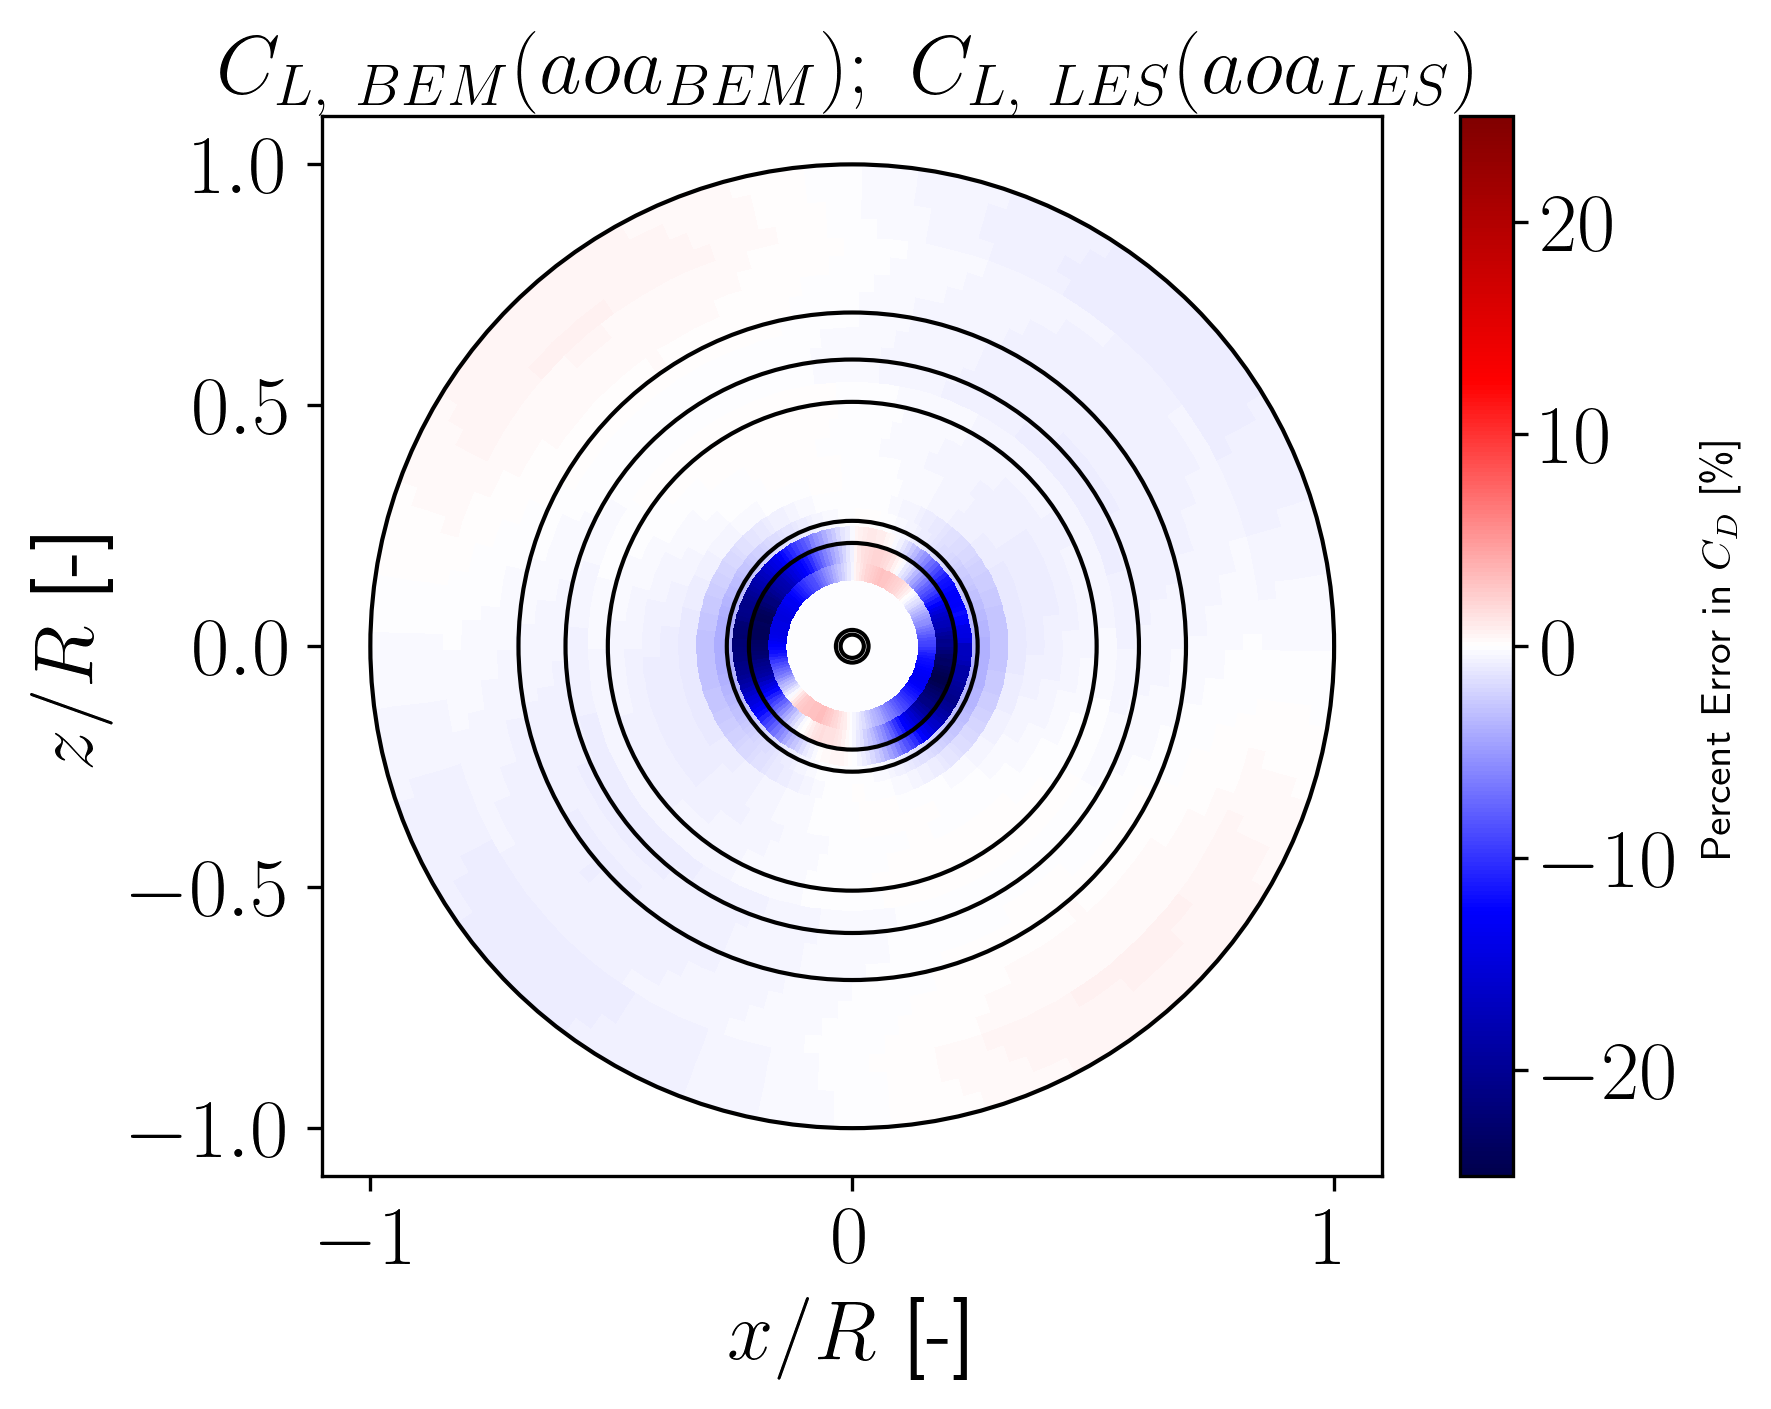

In [88]:
t = np.linspace(0,2*np.pi,wrfles_bem[0]['Nsct'])
r = wrfles_bem[0]['rOverR']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T))

airfoil_mu = np.array([0.0241206,  0.0338794,  0.21441709, 0.26028342, 0.5071809,  0.59501005, 0.69259799, 1.0])

fig, ax = plt.subplots(subplot_kw={'aspect': 'equal'})
pcm = ax.pcolormesh(X, Y, CD_err.T, shading='auto', cmap='seismic',vmin=-25,vmax = 25)
fig.colorbar(pcm, ax=ax, label='Percent Error in $C_D$ [\%]')
ax.set_xlabel('$x/R$ [-]',fontsize=fontsize)
ax.set_ylabel('$z/R$ [-]',fontsize=fontsize)
ax.set_title('$C_{L, \ BEM}(aoa_{BEM}); \ C_{L, \ LES}(aoa_{LES})$',fontsize=fontsize)
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])

# Add circles at each radius in airfoil_mu
for radius in airfoil_mu:
    circle = plt.Circle((0, 0), radius, color='black', fill=False, linewidth=1)
    ax.add_patch(circle)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2718569/815567352.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, aoa_err.T, shading='auto', cmap='seismic',vmin=-8,vmax=8)


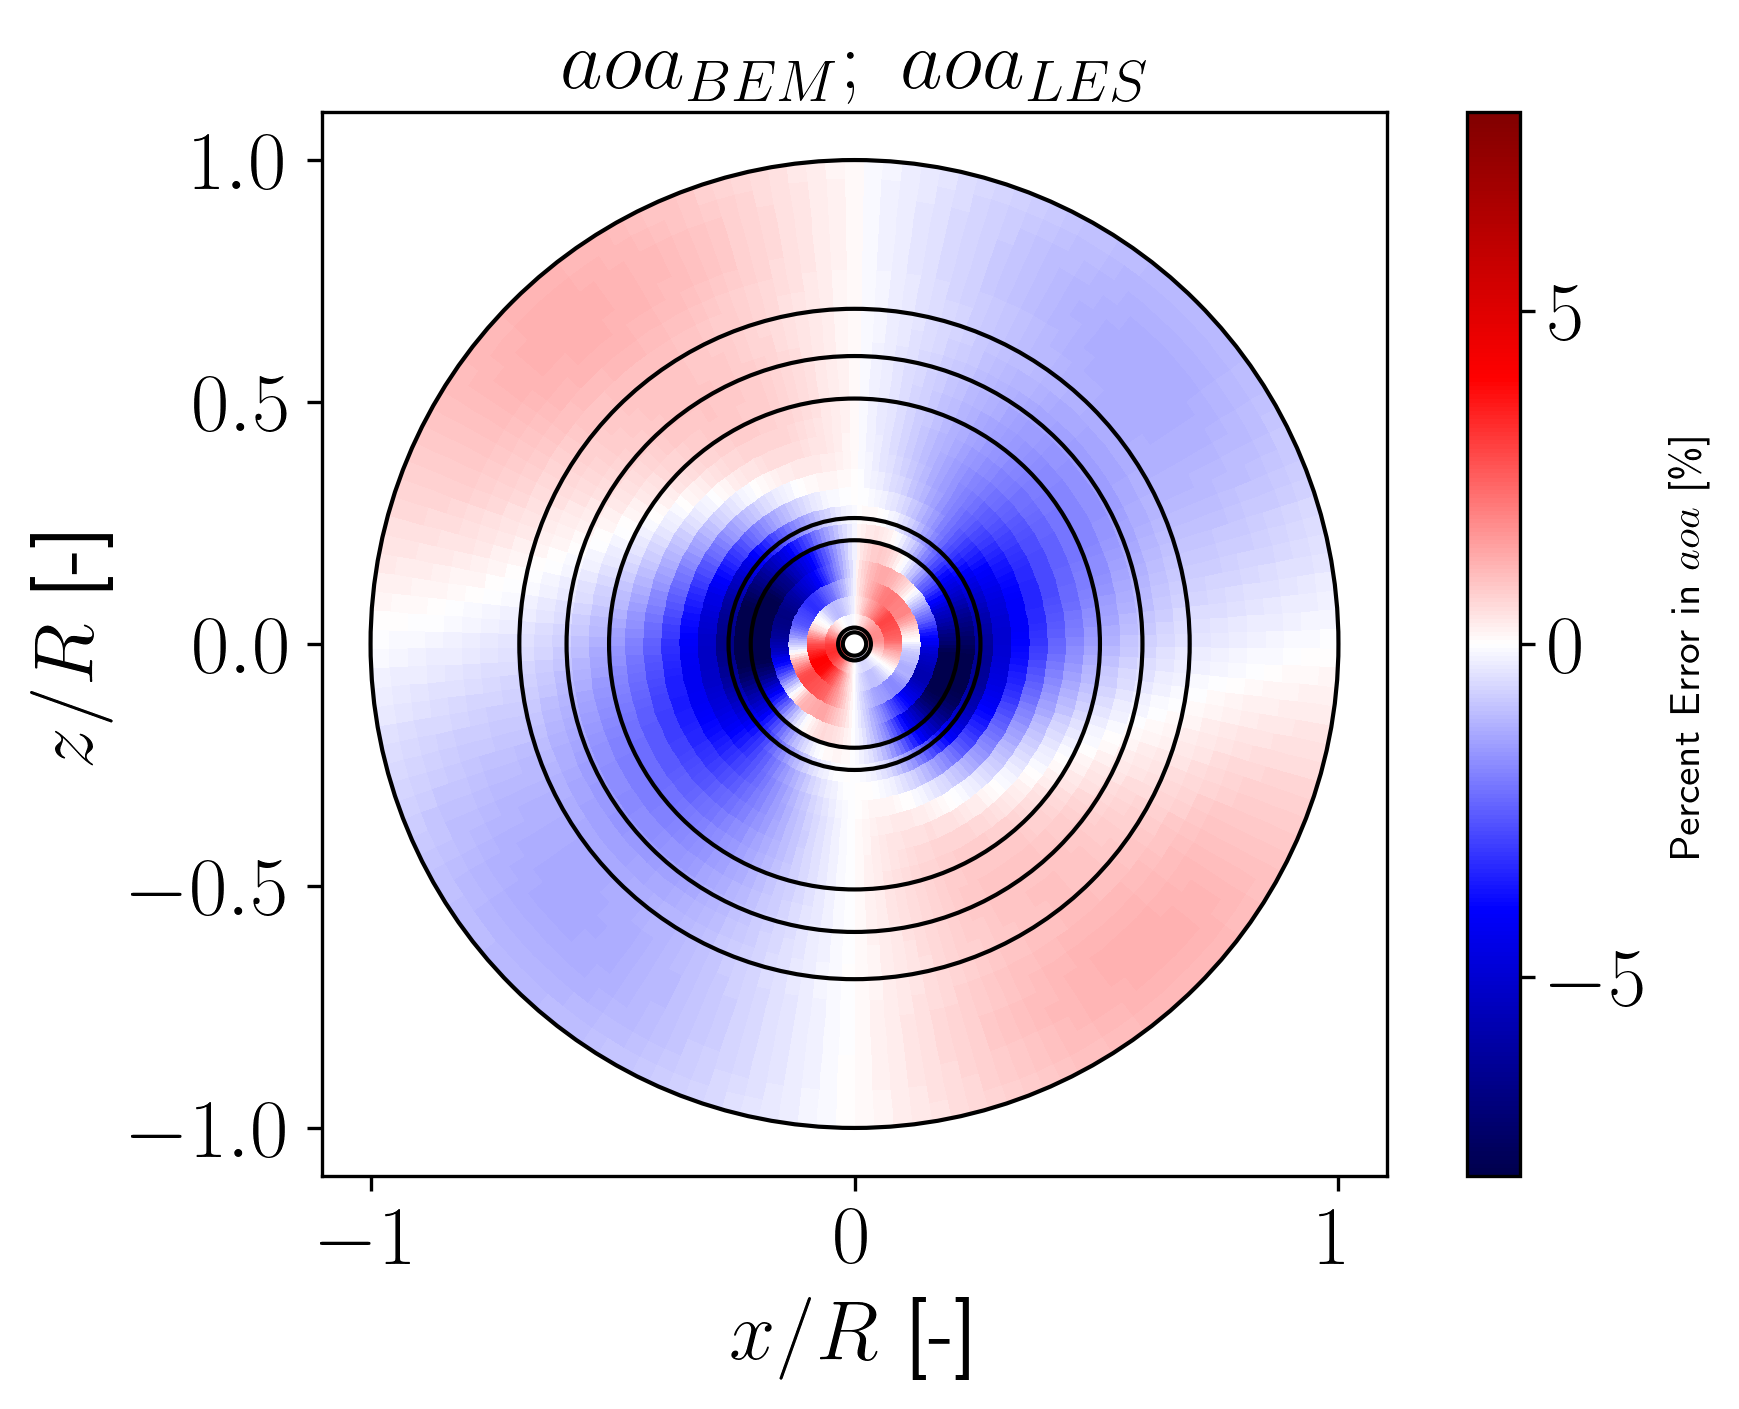

In [89]:
fig, ax = plt.subplots(subplot_kw={'aspect': 'equal'})
pcm = ax.pcolormesh(X, Y, aoa_err.T, shading='auto', cmap='seismic',vmin=-8,vmax=8)
fig.colorbar(pcm, ax=ax, label='Percent Error in $aoa$ [\%]')
ax.set_xlabel('$x/R$ [-]',fontsize=fontsize)
ax.set_ylabel('$z/R$ [-]',fontsize=fontsize)
ax.set_title('$aoa_{BEM}; \ aoa_{LES}$',fontsize=fontsize)
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])

# Add circles at each radius in airfoil_mu
for radius in airfoil_mu:
    circle = plt.Circle((0, 0), radius, color='black', fill=False, linewidth=1)
    ax.add_patch(circle)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2718569/3011712428.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, wrf_aoa[:,:,0].T, shading='auto', cmap='viridis', vmin=0.15,vmax=0.9)


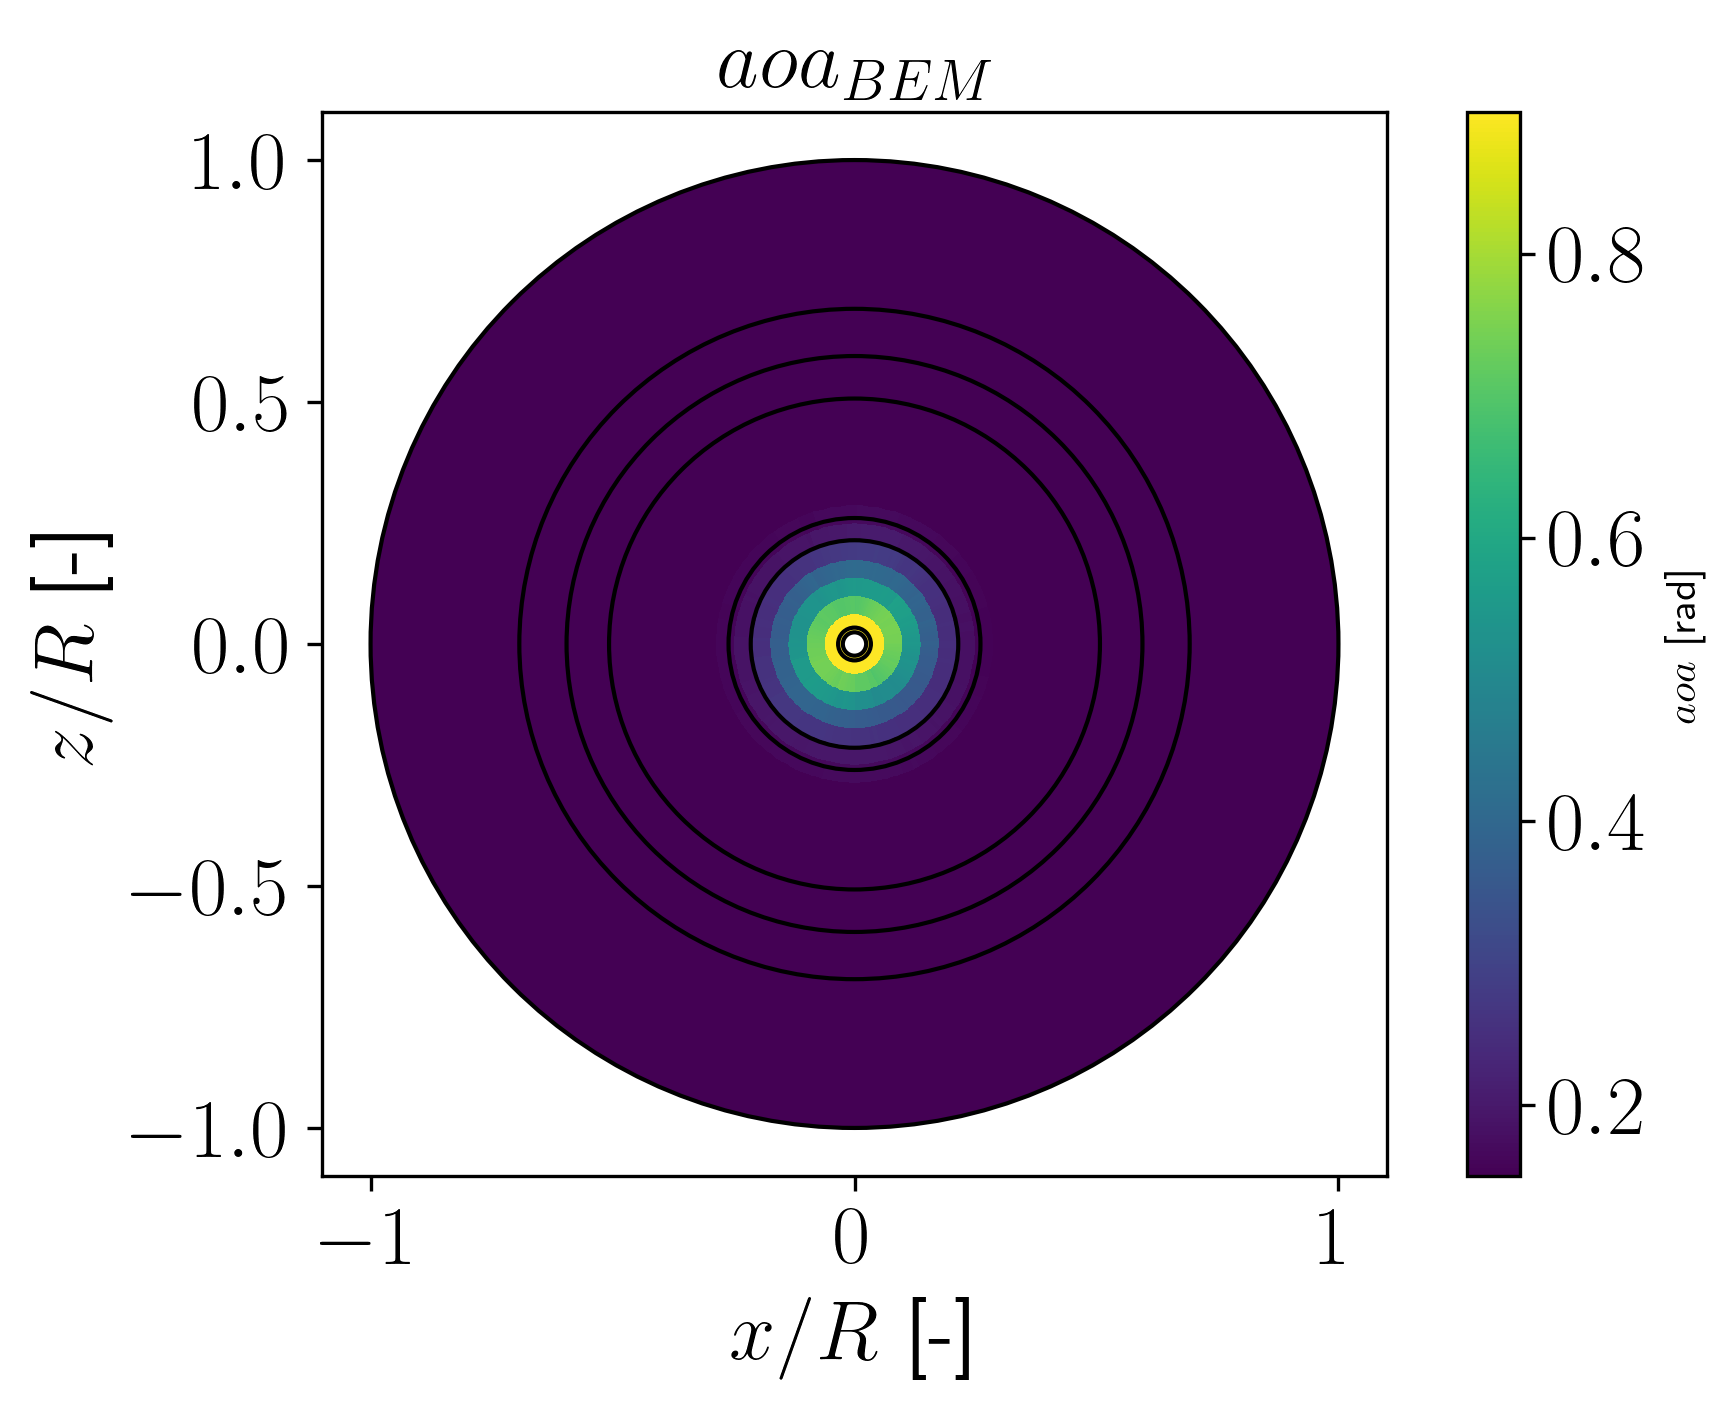

In [90]:
fig, ax = plt.subplots(subplot_kw={'aspect': 'equal'})
pcm = ax.pcolormesh(X, Y, wrf_aoa[:,:,0].T, shading='auto', cmap='viridis', vmin=0.15,vmax=0.9)
fig.colorbar(pcm, ax=ax, label='$aoa$ [rad]')
ax.set_xlabel('$x/R$ [-]',fontsize=fontsize)
ax.set_ylabel('$z/R$ [-]',fontsize=fontsize)
ax.set_title('$aoa_{BEM}$',fontsize=fontsize)
ax.set_xlim([-1.1,1.1])
ax.set_ylim([-1.1,1.1])

# Add circles at each radius in airfoil_mu
for radius in airfoil_mu:
    circle = plt.Circle((0, 0), radius, color='black', fill=False, linewidth=1)
    ax.add_patch(circle)

plt.tight_layout()
plt.show()

Text(0, 0.5, '$C_D$')

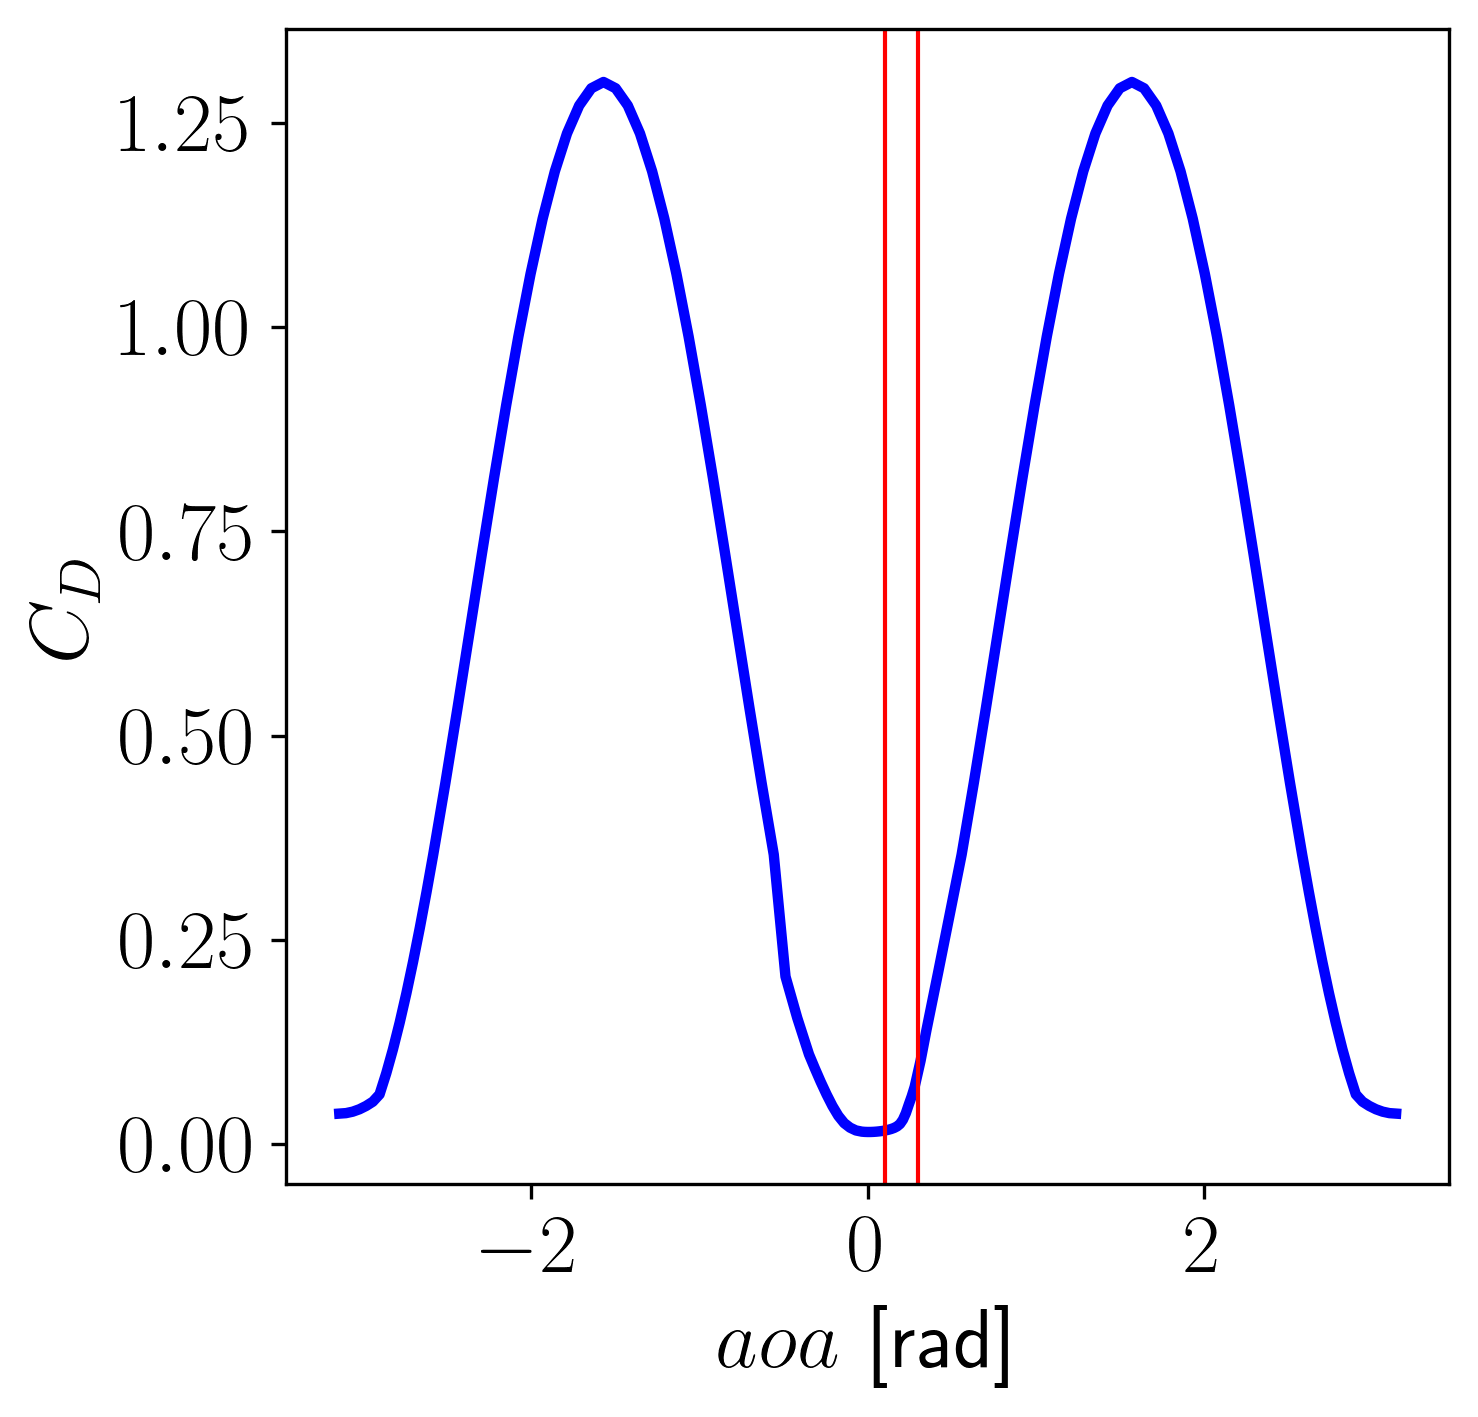

In [91]:
ref_cd_curve_grid = np.array([-3.141592653589793, -3.101699414, -3.061806173, -3.021912933, -2.98202, -2.94213, -2.902233213, -2.862339973, -2.82245, -2.78255, -2.74266, -2.70277, -2.662873773, -2.622980533, -2.583087293, -2.510780795, -2.438474298, -2.3661678, -2.293861303, -2.221554805, -2.149248307, -2.07694181, -2.004635312, -1.932328815, -1.860022317, -1.78771582, -1.715409322, -1.643102824, -1.570796327, -1.498489829, -1.426183332, -1.353876834, -1.281570336, -1.209263839, -1.136957341, -1.064650844, -0.992344346, -0.920037849, -0.847731351, -0.775424853, -0.703118356, -0.630811858, -0.558505361, -0.488692191, -0.41887902, -0.34906585, -0.314159265, -0.27925268, -0.244346095, -0.20943951, -0.174532925, -0.13962634, -0.104719755, -0.06981317, -0.034906585, -0.017453293, 0, 0.017453293, 0.034906585, 0.052359878, 0.06981317, 0.087266463, 0.104719755, 0.122173048, 0.13962634, 0.157079633, 0.174532925, 0.191986218, 0.20943951, 0.226892803, 0.244346095, 0.261799388, 0.27925268, 0.314159265, 0.34906585, 0.41887902, 0.488692191, 0.558505361, 0.630811858, 0.703118356, 0.775424853, 0.847731351, 0.920037849, 0.992344346, 1.064650844, 1.136957341, 1.209263839, 1.281570336, 1.353876834, 1.426183332, 1.498489829, 1.570796327, 1.643102824, 1.715409322, 1.78771582, 1.860022317, 1.932328815, 2.004635312, 2.07694181, 2.149248307, 2.221554805, 2.293861303, 2.3661678, 2.438474298, 2.510780795, 2.583087293, 2.622980533, 2.662873773, 2.702767013, 2.742660253, 2.782553493, 2.822446733, 2.862339973, 2.902233213, 2.942126453, 2.982019693, 3.021912933, 3.061806173, 3.101699414, 3.141592653589793])
ref_cd_curve = np.array([0.03714766955647932, 0.03773901133374287, 0.03950914701885524, 0.04244639553319605, 0.04653137791244361, 0.05173713798667876, 0.06067799498087878, 0.08650795664630631, 0.1158646406574733, 0.1485619804842812, 0.1843927466024767, 0.2231298637078226, 0.2645278540548881, 0.3083243977394954, 0.354242, 0.4419239296599637, 0.5337885553342574, 0.6279269922758957, 0.7223836823125198, 0.8151971682421021, 0.9044409874864893, 0.9882638315724093, 1.064928133355331, 1.132846276742087, 1.190613673317614, 1.237038015703063, 1.271164097300969, 1.29229368065155, 1.3, 1.29229368065155, 1.271164097300969, 1.237038015703063, 1.190613673317614, 1.132846276742087, 1.064928133355331, 0.9882638315724093, 0.9044409874864896, 0.8151971682421021, 0.7223836823125203, 0.6279269922758957, 0.5337885553342576, 0.4419239296599635, 0.354242, 0.204936, 0.154343, 0.1096723, 0.09248859999999999, 0.07597419999999999, 0.0605412, 0.0464115, 0.0344101, 0.0254821, 0.0199403, 0.0165337, 0.0150697, 0.0147703, 0.0146486, 0.0146633, 0.0148131, 0.0150716, 0.0154399, 0.0159264, 0.0165411, 0.0173108, 0.0183096, 0.0196309, 0.0214988, 0.0244544, 0.0296621, 0.0376996, 0.0482436, 0.0583757, 0.0699237, 0.1016591, 0.139159, 0.210024, 0.282003, 0.354242, 0.4419239296599635, 0.5337885553342578, 0.6279269922758957, 0.7223836823125203, 0.8151971682421021, 0.9044409874864896, 0.9882638315724093, 1.064928133355331, 1.132846276742087, 1.190613673317614, 1.237038015703063, 1.271164097300969, 1.29229368065155, 1.3, 1.29229368065155, 1.271164097300969, 1.237038015703063, 1.190613673317614, 1.132846276742087, 1.064928133355331, 0.9882638315724093, 0.9044409874864899, 0.8151971682421021, 0.7223836823125198, 0.6279269922758957, 0.5337885553342574, 0.4419239296599637, 0.354242, 0.3083243977394954, 0.2645278540548881, 0.2231298637078226, 0.1843927466024767, 0.1485619804842812, 0.1158646406574736, 0.08650795664630631, 0.06067799498087906, 0.05173713798667876, 0.04653137791244361, 0.04244639553319605, 0.03950914701885524, 0.03773901133374287, 0.03714766955647932])

fig, ax = plt.subplots(figsize=(5, 5))

ax.plot(ref_cd_curve_grid, ref_cd_curve, color='b', linewidth=2.5)

ax.axvline(0.3, color='r', linewidth=1)
ax.axvline(0.1, color='r', linewidth=1)

ax.set_xlabel('$aoa$ [rad]',fontsize=fontsize)
ax.set_ylabel('$C_D$',fontsize=fontsize)

/tmp/ipykernel_2718569/2280369173.py:5: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, CD_err.T, shading='auto', cmap='seismic',vmin=-0.3,vmax=0.3)


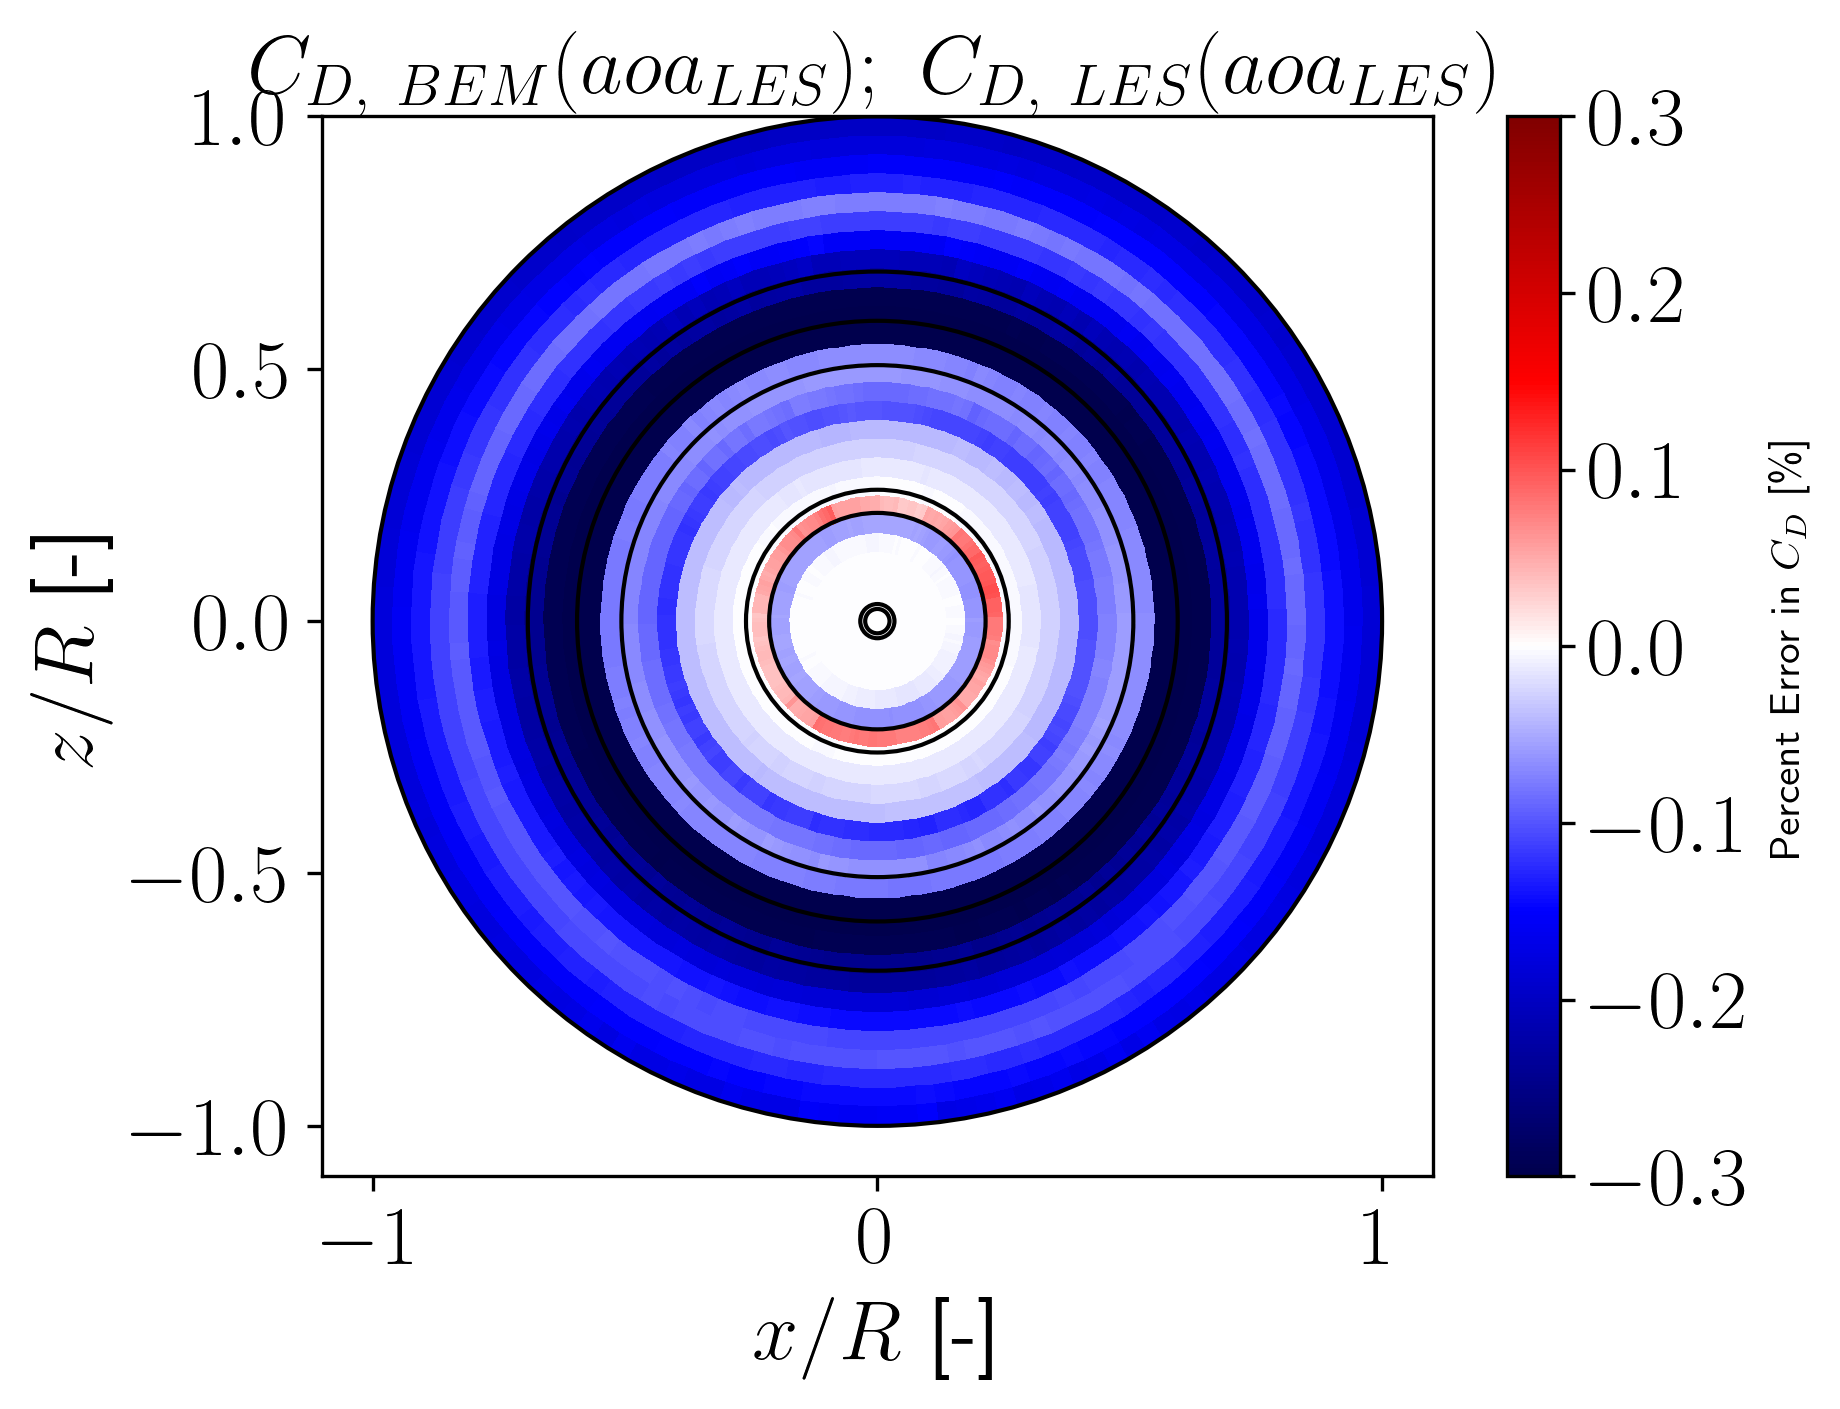

In [92]:
_, Cd_with_les_aoa = rotor.clcd(r_mat, wrf_aoa_real[:,:,0])
CD_err = postproc.per_error(Cd_with_les_aoa, wrf_CD_real[:,:,0])

fig, ax = plt.subplots(subplot_kw={'aspect': 'equal'})
pcm = ax.pcolormesh(X, Y, CD_err.T, shading='auto', cmap='seismic',vmin=-0.3,vmax=0.3)
fig.colorbar(pcm, ax=ax, label='Percent Error in $C_D$ [\%]')
ax.set_xlabel('$x/R$ [-]',fontsize=fontsize)
ax.set_ylabel('$z/R$ [-]',fontsize=fontsize)
ax.set_title('$C_{D, \ BEM}(aoa_{LES}); \ C_{D, \ LES}(aoa_{LES})$',fontsize=fontsize)

# Add circles at each radius in airfoil_mu
for radius in airfoil_mu:
    circle = plt.Circle((0, 0), radius, color='black', fill=False, linewidth=1)
    ax.add_patch(circle)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2718569/3356062023.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, vax_err.T, shading='auto', cmap='seismic',vmin=-0.0125,vmax=0.0125)


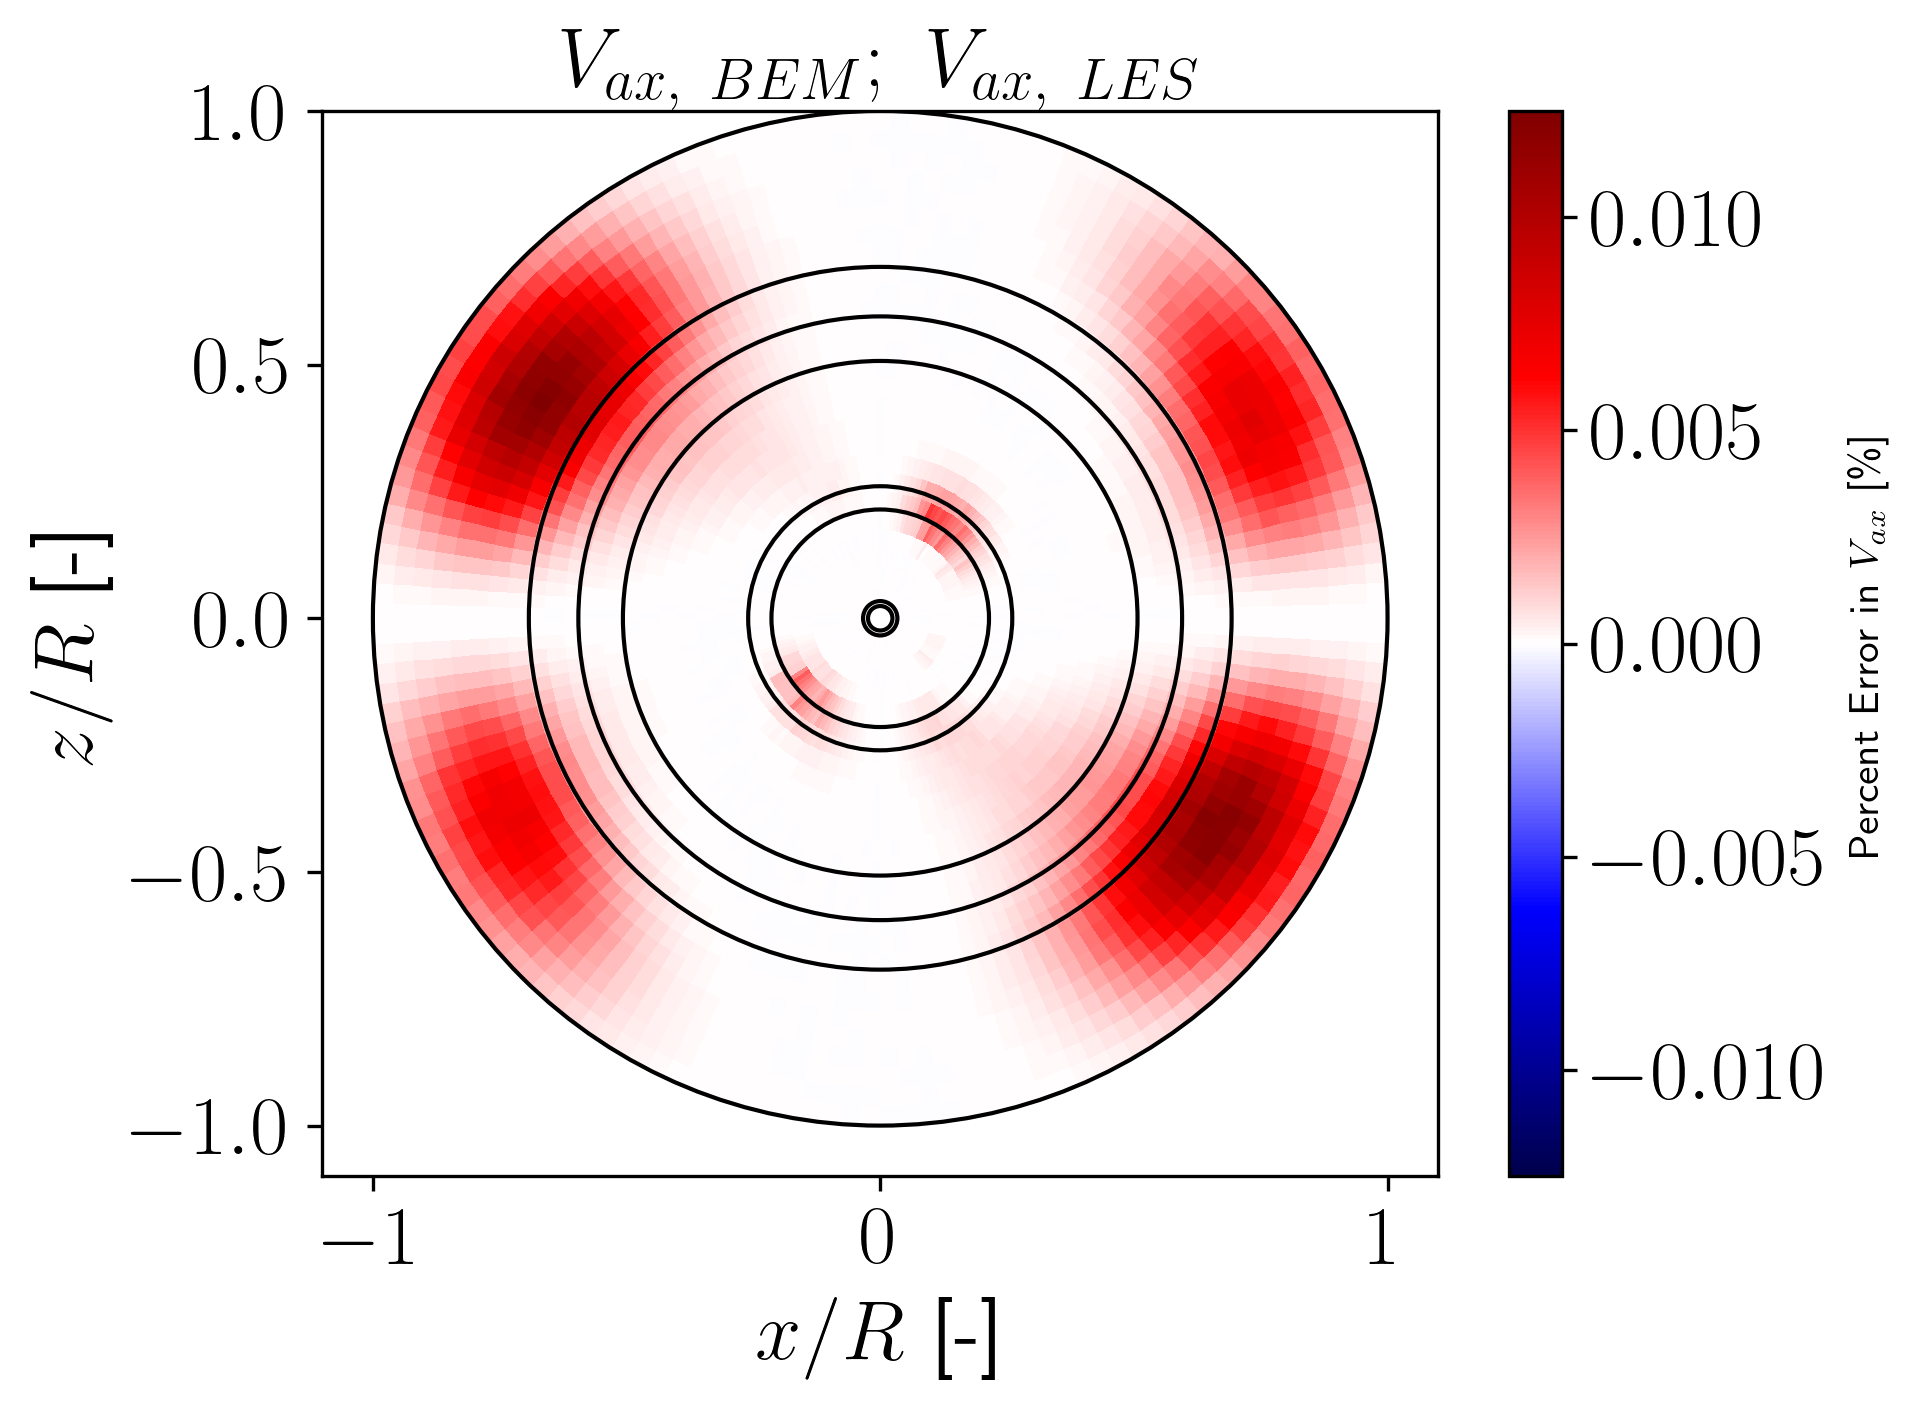

In [93]:
vax_err = postproc.per_error(wrf_vax[:,:,0], wrf_vax_real[:,:,0])

fig, ax = plt.subplots(subplot_kw={'aspect': 'equal'})
pcm = ax.pcolormesh(X, Y, vax_err.T, shading='auto', cmap='seismic',vmin=-0.0125,vmax=0.0125)
fig.colorbar(pcm, ax=ax, label='Percent Error in $V_{ax}$ [\%]')
ax.set_xlabel('$x/R$ [-]',fontsize=fontsize)
ax.set_ylabel('$z/R$ [-]',fontsize=fontsize)
ax.set_title('$V_{ax, \ BEM}; \ V_{ax, \ LES}$',fontsize=fontsize)

# Add circles at each radius in airfoil_mu
for radius in airfoil_mu:
    circle = plt.Circle((0, 0), radius, color='black', fill=False, linewidth=1)
    ax.add_patch(circle)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2718569/1636152809.py:4: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(X, Y, vtn_err.T, shading='auto', cmap='seismic',vmin=-7,vmax=7)


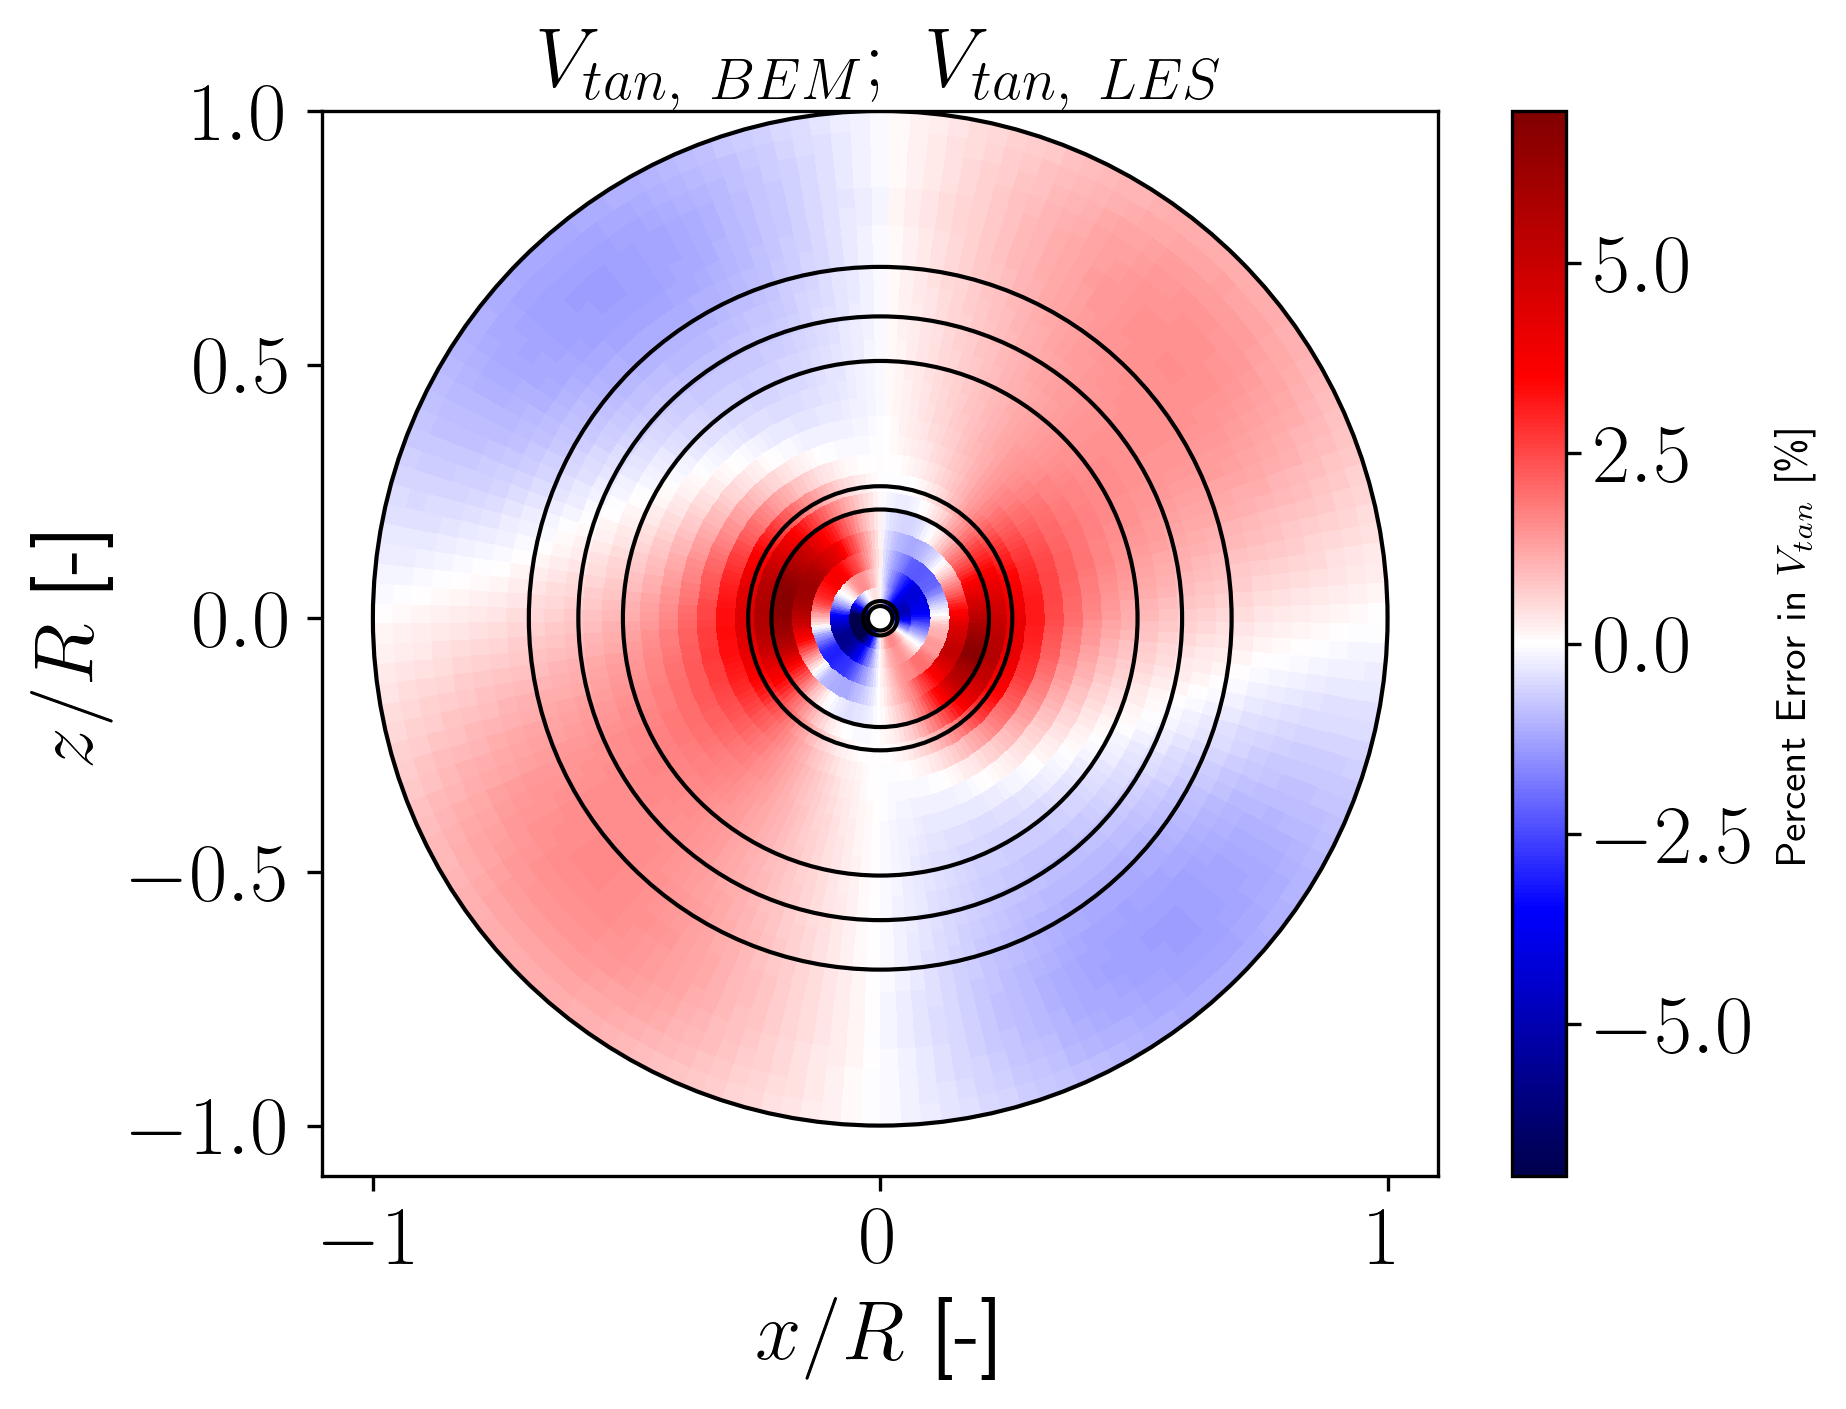

In [94]:
vtn_err = postproc.per_error(wrf_vtn[:,:,0], wrf_vtn_real[:,:,0])

fig, ax = plt.subplots(subplot_kw={'aspect': 'equal'})
pcm = ax.pcolormesh(X, Y, vtn_err.T, shading='auto', cmap='seismic',vmin=-7,vmax=7)
fig.colorbar(pcm, ax=ax, label='Percent Error in $V_{tan}$ [\%]')
ax.set_xlabel('$x/R$ [-]',fontsize=fontsize)
ax.set_ylabel('$z/R$ [-]',fontsize=fontsize)
ax.set_title('$V_{tan, \ BEM}; \ V_{tan, \ LES}$',fontsize=fontsize)

# Add circles at each radius in airfoil_mu
for radius in airfoil_mu:
    circle = plt.Circle((0, 0), radius, color='black', fill=False, linewidth=1)
    ax.add_patch(circle)

plt.tight_layout()
plt.show()